In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, f1_score, recall_score,
                              precision_score, accuracy_score, roc_auc_score)

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

In [2]:
lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['No Disease','Disease']))
joblib.dump(lr, 'lr_model.pkl')

              precision    recall  f1-score   support

  No Disease       0.90      0.85      0.88        82
     Disease       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



['lr_model.pkl']

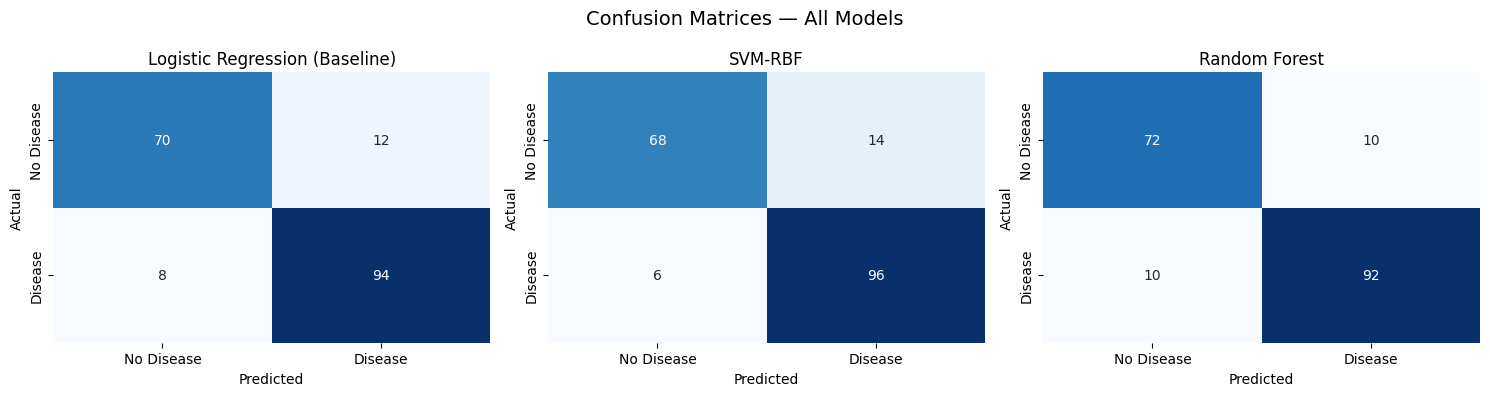

In [6]:
models_eval = {
    'Logistic Regression (Baseline)': (joblib.load('lr_model.pkl'),  None),
    'SVM-RBF': (joblib.load('svm_model.pkl'), None),
    'Random Forest':  (joblib.load('rf_model.pkl'),  None),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, (model, _)) in enumerate(models_eval.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

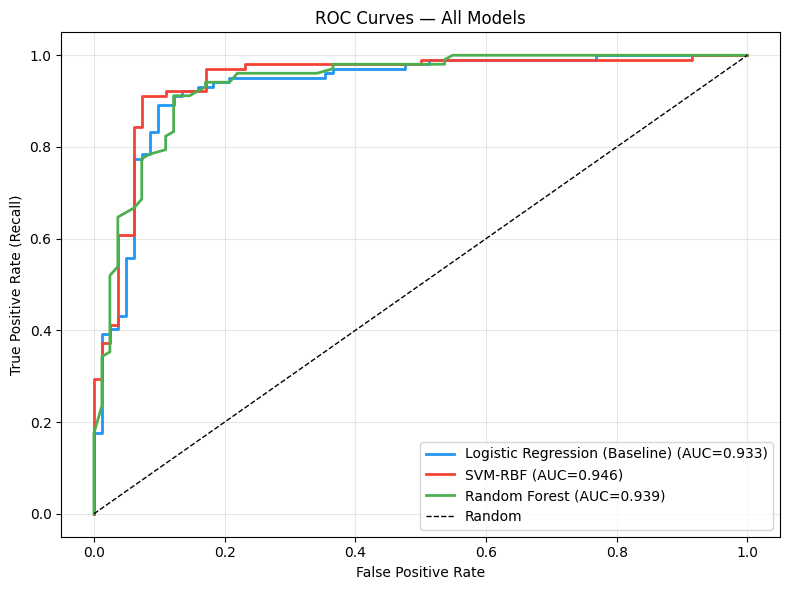

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#F44336', '#4CAF50']

for (name, (model, _)), color in zip(models_eval.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()